In [55]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
from anndata import AnnData
#from muon import prot as pt
from sklearn import preprocessing
from collections import defaultdict
import seaborn as sns
input_dir = 'pre_processed_files/'
output_fig = 'figures'
def strip_extension(self):
    '''strip the file extension from a pd.Series of file names'''
    return self.apply(lambda x: os.path.splitext(x)[0])

# Add the method to the Pandas Series class
pd.Series.strip_extension = strip_extension

Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from AnnoSpat

cell type annotation comes from AnnoSpat

In [56]:
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv').drop('item',axis = 1)
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv').drop('item',axis = 1)
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types


read intensities ( protein level per cell)

In [57]:
intensities = pd.read_csv(input_dir+'/all_data_intensities.csv',index_col=0)
intensities.index = intensities.index.astype(str)
cond = intensities.slice_ID.str.split('_').str[0].isin(['Leap001','Leap002'])


In [58]:


#for now take only Leap1 and Leap2 because they are the only with regionsprop
cond = intensities.slice_ID.str.split('_').str[0].isin(['Leap001','Leap002'])
intensities = intensities[cond]
labels = labels[cond.values]

columns_to_extract = intensities.columns.difference(['slice_ID'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)
'''
if set(intensities.source_file.str[:7]) != {'Leap001', 'Leap002'}:
    raise ValueError ('this code works only for all_data folder, change it')
intensities['resection'] = intensities.source_file.str[:7]=='Leap002'
'''

"\nif set(intensities.source_file.str[:7]) != {'Leap001', 'Leap002'}:\n    raise ValueError ('this code works only for all_data folder, change it')\nintensities['resection'] = intensities.source_file.str[:7]=='Leap002'\n"

In [59]:

signature_sign = pd.read_csv('metadata/cell_type_matrix.csv').fillna(0)
marker_list = (signature_sign!=0).any(axis = 1)
#marker_list = list(marker_list[marker_list].index)
marker_list = list(signature_sign[marker_list]['Marker'])

The variable`regions` contains the spatial properties of the cells. Cell geometry and location is obtained from ilastik and CellProfiler

In [60]:
regions = pd.read_csv(input_dir+'/all_data_regions.csv',index_col=0)
regions.head()

,centroid-0,centroid-1,major_axis_length,minor_axis_length,eccentricity,slice_ID
area,,,,,,
43,2.023256,3.651163,9.676062,6.313480,0.757802,Leap001_010
11,0.727273,14.272727,4.899297,2.919900,0.802997,Leap001_010
75,2.800000,34.920000,14.396862,7.302144,0.861826,Leap001_010
54,3.092593,54.851852,12.421144,6.501067,0.852095,Leap001_010
34,2.235294,67.205882,7.218268,6.542414,0.422487,Leap001_010


N. of cells by experiments

<Figure size 432x288 with 0 Axes>

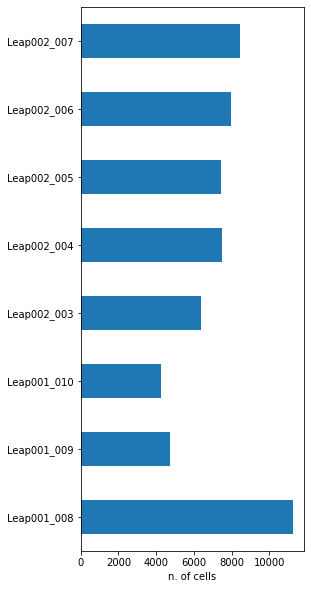

<Figure size 432x288 with 0 Axes>

In [61]:
plt.figure(figsize = (4,10))
intensities.slice_ID.value_counts().sort_index().plot(kind = 'barh')
plt.xlabel('n. of cells')
plt.figure()


In [62]:
intensities.slice_ID.value_counts().index

Index(['Leap001_008', 'Leap002_007', 'Leap002_006', 'Leap002_004',
       'Leap002_005', 'Leap002_003', 'Leap001_009', 'Leap001_010'],
      dtype='object')

Load the expert curated signature table

In [63]:
#regions.area.hist()

#pt.pp.clr(adata)

Using the analysis of [squidpy](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_read_spatial.html) 

In AnnoSpat authors log-transform the counts, and normalise every cell to have $L_2$ norm 1

In [64]:
adata

AnnData object with n_obs × n_vars = 58031 × 37
    obsm: 'spatial'

In [65]:
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['AnnoSpat'] = pd.Categorical(labels.label.values.astype(str))


#“centered log ratio"
sc.pp.log1p(adata)

#sc.pp.normalize_total(adata)# it uses the l1 norm, we like the l2 instead
adata.X = preprocessing.normalize(adata.X, norm='l2')
sc.pp.pca(adata,n_comps=25)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)


<ipython-input-65-f9f7d52e132a>:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})


In [66]:
#adata.obs['ROI'] =  intensities.ROI
adata.obs['slice_ID'] = intensities.slice_ID
intensities['patient']= intensities.slice_ID.str.split('_').str[0]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


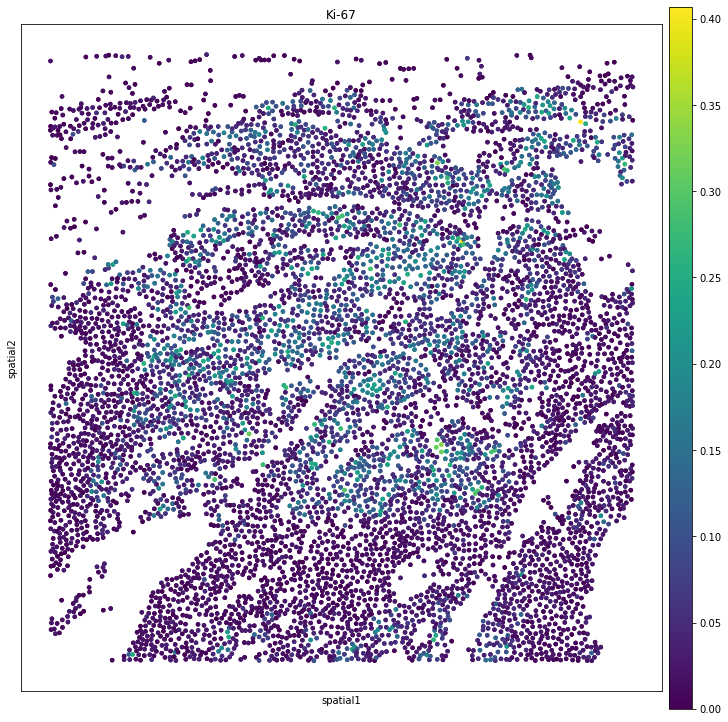

In [67]:
sq.pl.spatial_scatter(adata[adata.obs.slice_ID =='Leap002_005'], shape=None, color="Ki-67", size=50,figsize = (10,10))


take picture of a specific file, do not mix ROIs together

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


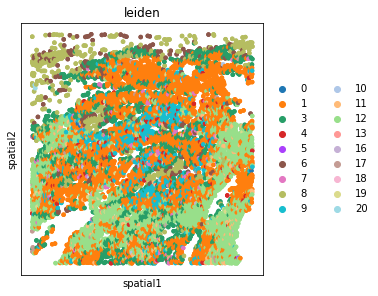

In [14]:
sq.pl.spatial_scatter(adata[adata.obs.slice_ID =='Leap002_005'], shape=None, color="leiden", size=50)
#plt.savefig(output_fig+'/spatial_ROI2.png')

16

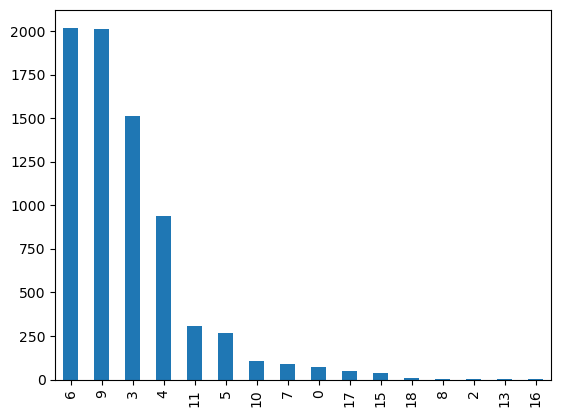

In [42]:
adata[adata.obs.filename =='Leap002_005'].obs.leiden.value_counts().plot(kind = 'bar')
len(adata[adata.obs.filename =='Leap002_005'].obs.leiden.value_counts())

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


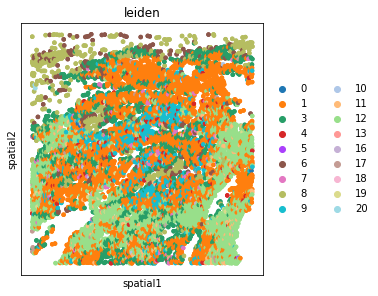

In [70]:
sq.pl.spatial_scatter(adata[adata.obs.slice_ID =='Leap002_005'], shape=None, color="leiden", size=50)


<Axes: >

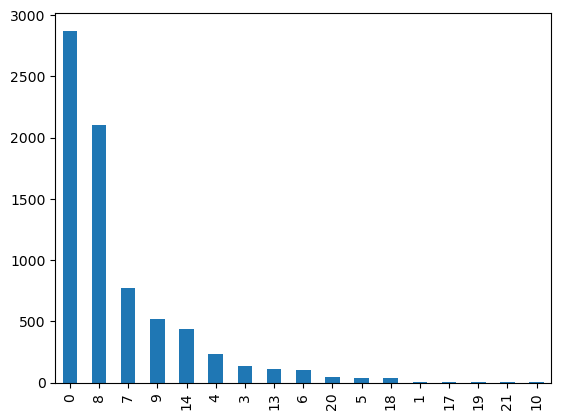

In [30]:
adata[adata.obs.filename =='Leap002_005'].obs.leiden.value_counts().plot(kind = 'bar')

<Axes: >

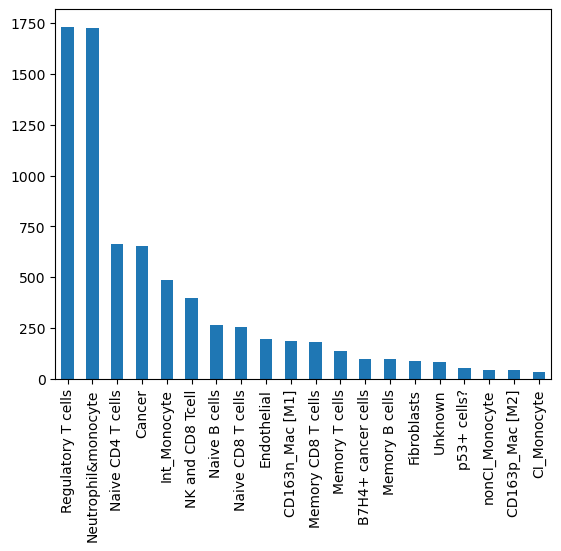

In [31]:
adata[adata.obs.filename =='Leap002_005'].obs.AnnoSpat.value_counts().plot(kind = 'bar')

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
<ipython-input-15-320f884ff5f3>:2: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


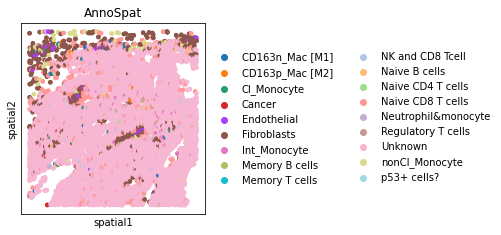

In [15]:
sq.pl.spatial_scatter(adata[adata.obs.slice_ID =='Leap002_005'], shape=None, color="AnnoSpat", size=50)
plt.tight_layout()
#plt.savefig(output_fig+'/spatial_ROI2.png')

Below I compute the dot product between the dotplot matrix ( average expression of a protein in a cluster) and the signature matrix. It gives a value between [-1,1] so that the highest the better

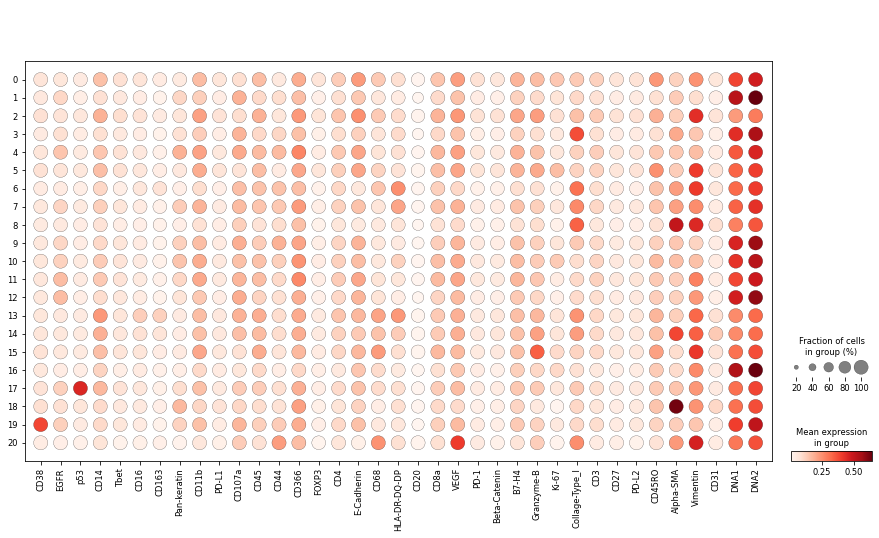

<AxesSubplot:ylabel='leiden'>

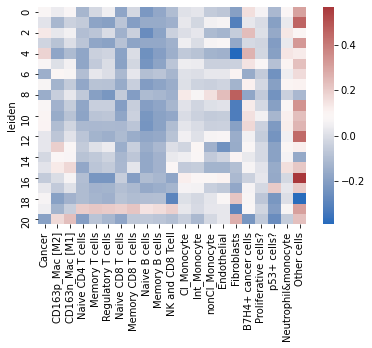

In [18]:
#sc.pl.dotplot(adata, var_names = marker_list, groupby = "AnnoSpat")
def create_dotplot(adata,groupby):
    '''
    compute the correlation between the dotplot and the manually curated marker table
    '''
    dotplot = sc.pl.dotplot(adata, var_names = marker_list, groupby = groupby,return_fig=True)
    dotplot.show()
    dot_color = dotplot.dot_color_df
    corr = (dot_color-(dot_color.max(axis = 0)/2))@signature_sign.set_index('Marker').loc[marker_list]
    return corr
corr_leiden = create_dotplot(adata,'leiden')
sns.heatmap(corr_leiden,cmap='vlag')

In [34]:
adata.obs.AnnoSpat.value_counts(normalize=True)

Unknown                0.521532
NK and CD8 Tcell       0.227982
Naive CD8 T cells      0.089090
Fibroblasts            0.044821
Endothelial            0.031225
nonCI_Monocyte         0.015474
Int_Monocyte           0.015130
Memory T cells         0.015044
Memory B cells         0.009857
Naive B cells          0.005239
CI_Monocyte            0.005187
Neutrophil&monocyte    0.005101
CD163p_Mac [M2]        0.004739
CD163n_Mac [M1]        0.004549
B7H4+ cancer cells     0.002481
Naive CD4 T cells      0.001637
Memory CD8 T cells     0.000569
Regulatory T cells     0.000345
Name: AnnoSpat, dtype: float64

In the case of the AnnoSpat, I expect that the element in the diagonal are the heighest of the column

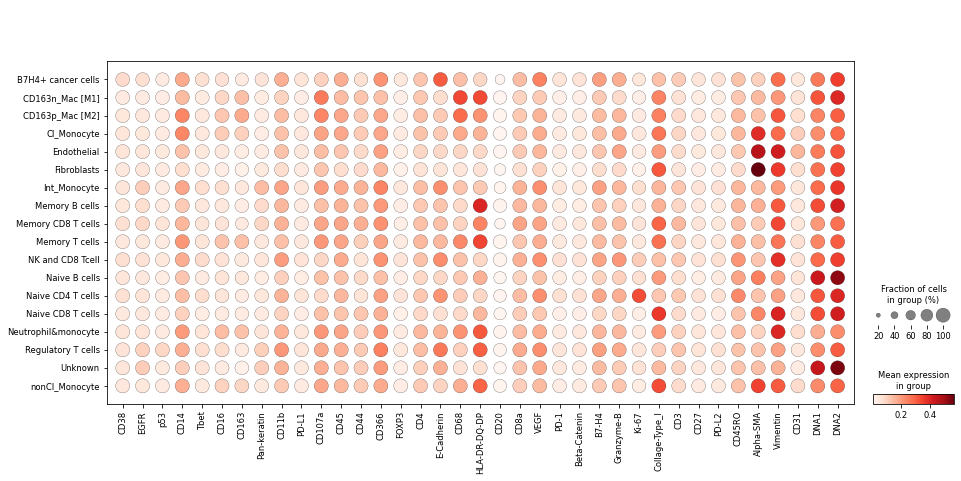

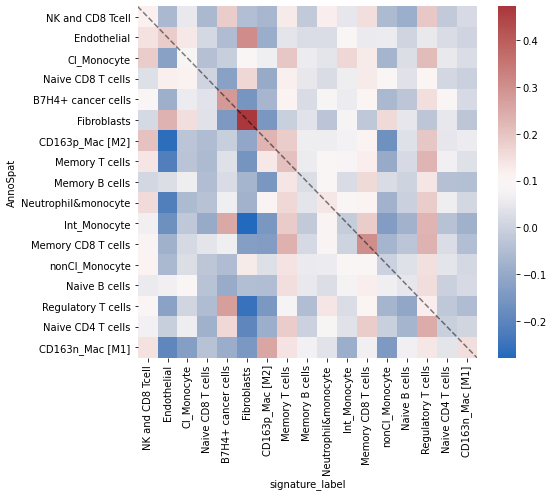

In [19]:
corr_anno = create_dotplot(adata,'AnnoSpat')
plt.figure(figsize = (8,7))
l = list(labels.label.unique())
l.remove('Unknown')
sns.heatmap(corr_anno.loc[l,l],cmap='vlag')
plt.xlabel('signature_label')

plt.plot([0,len(adata.obs.AnnoSpat.value_counts())],[0,len(adata.obs.AnnoSpat.value_counts())],'k--',alpha = 0.5)
plt.tight_layout()
#plt.savefig(output_fig+'/label_overlap.png')

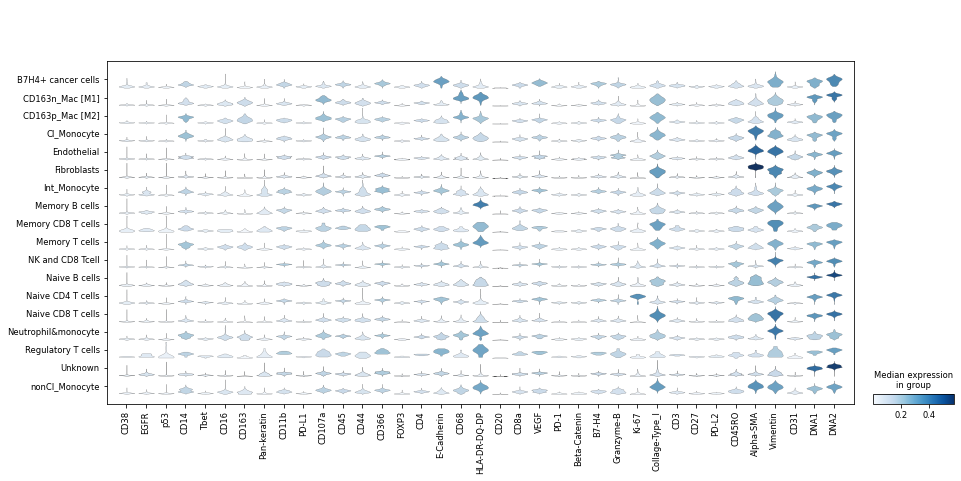

<Figure size 432x288 with 0 Axes>

In [51]:
sc.pl.stacked_violin(adata, marker_list, groupby='AnnoSpat', rotation=90,save='.png')
plt.tight_layout()
#plt.savefig(output_fig+'/violin.png')

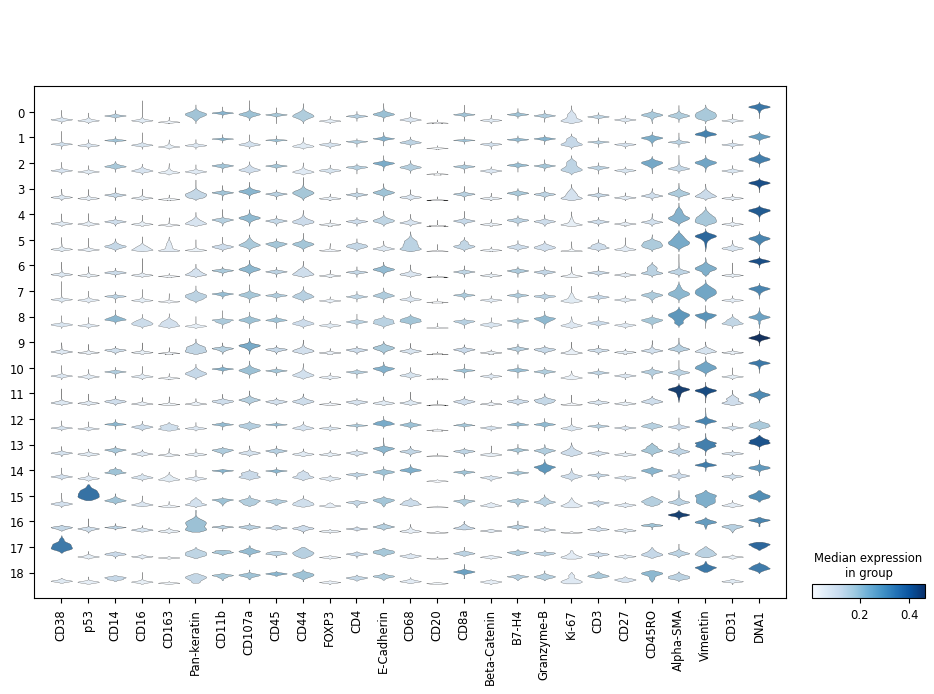

<Figure size 640x480 with 0 Axes>

In [48]:
sc.pl.stacked_violin(adata, marker_list, groupby='leiden', rotation=90,save='.png')
plt.tight_layout()

use sc.tl.rank_genes_groups

mapping from cell type label to name

In [ ]:
pd.DataFrame.from_dict(mapper,orient='index',columns=['Cell_type']).sort_index()#for AnnoSpat, this is the mapping from cell type label to name

In [213]:

## for the named clusters, do the markers (and is there fast way of checking)

## for each marker gene that appears at all, make a set of violin plots for all
## cell types that have that marker in the list, and look if higher in "high" and 
## lower in "low" (and label somewhere on the fig which should be high/low)

## importing the signature file and then check are they "high"
signature = pd.read_csv('processed_files/signature.csv',index_col=0)

## with the unnamed ones, can we try to manually annotate them 
## for the leiden, which AnnoSpat labels are most frequent? 
## (maybe a cross-correlation matrix?)




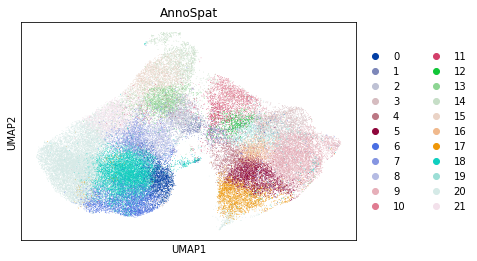

In [53]:
sc.pl.umap(adata,color='AnnoSpat')

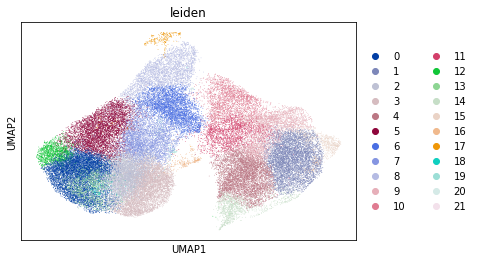

In [10]:
sc.pl.umap(adata,color='leiden')

In [19]:
adata.shape

(58031, 37)

  0%|          | 0/1000 [00:00<?, ?/s]

<ipython-input-173-c291ccb6065f>:8: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


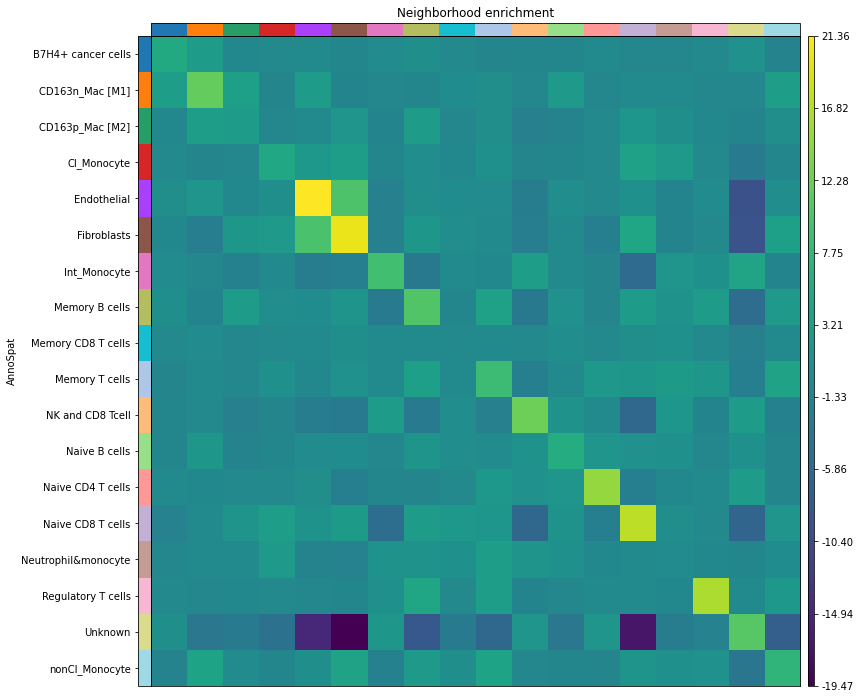

In [173]:
sub_adata = adata[adata.obs.slice_ID.isin(['Leap002_002','Leap002_003','Leap002_004','Leap002_005','Leap002_006','Leap002_007'])]
#sub_adata = adata
sq.gr.spatial_neighbors(sub_adata)
sq.gr.nhood_enrichment(sub_adata, cluster_key='AnnoSpat')
#sq.pl.nhood_enrichment(adata, cluster_key='AnnoSpat',save='/enrichment.png')
sq.pl.nhood_enrichment(sub_adata, cluster_key='AnnoSpat')
plt.xlabel('Cell type')
plt.tight_layout()

In [179]:
A = sub_adata.uns['AnnoSpat_nhood_enrichment']['zscore']

(18, 18)

In [197]:
enrich_list = pd.DataFrame()
for ID in ['Leap002_003','Leap002_004','Leap002_005','Leap002_006','Leap002_007']:
    sub_adata = adata[adata.obs.slice_ID==ID]
    sq.gr.spatial_neighbors(sub_adata)
    sq.gr.nhood_enrichment(sub_adata, cluster_key='AnnoSpat')
    A = sub_adata.uns['AnnoSpat_nhood_enrichment']['zscore']
    a = np.array(sub_adata.obs['AnnoSpat'].cat.categories)#label list
    

    

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in true_divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in true_divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in true_divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in true_divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


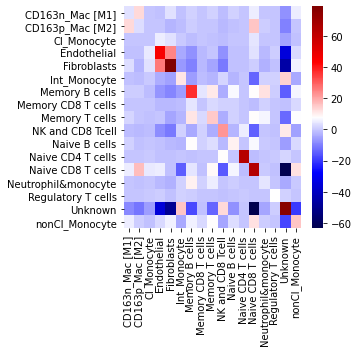

In [207]:
plt.figure(figsize = (5,5))
sns.heatmap(pd.DataFrame(A,index=a,columns=a),cmap='seismic',xticklabels=True)
plt.tight_layout()
#plt.savefig('./figures/enrichment.png')

In [184]:
adata.obs.slice_ID.value_counts()

Leap001_008    11285
Leap002_007     8471
Leap002_006     7998
Leap002_004     7486
Leap002_005     7418
Leap002_003     6399
Leap001_009     4741
Leap001_010     4233
Name: slice_ID, dtype: int64

# statistics of enrichment for non responder
after treatment


In [168]:
dic = defaultdict(list)
for ID in ['Leap002_002','Leap002_003','Leap002_004','Leap002_005','Leap002_006','Leap002_007']:
    sub_adata = adata[adata.obs.slice_ID==ID]
    a = np.array(sub_adata.obs['AnnoSpat'].cat.categories)#label list

    key0 = 'Naive CD8 T cells'
    key1 =  'Regulatory T cells'
    key2 = 'Naive B cells'
    if ((key0 in a)&((key1 in a) | (key2 in a))): 
        sq.gr.co_occurrence(sub_adata, cluster_key="AnnoSpat",n_splits=1)
        x = sub_adata.uns['AnnoSpat_co_occurrence']['interval'][1:]

        if (key1 in a):
            y1 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a ==key1])
            dic[key1]+=[y1]
        if (key2 in a):
            y2 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a == key2])
            dic[key2]+=[y2]

  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


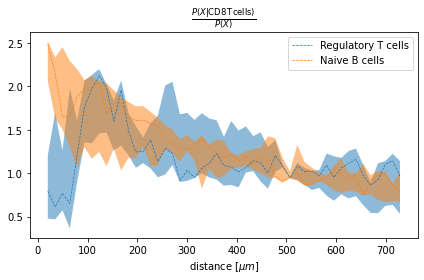

In [170]:
plt.plot(x,np.median(dic[key1],axis = 0),label = key1,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key1], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)

plt.plot(x,np.median(dic[key2],axis = 0),label = key2,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key2], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)
plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CD8 \,T cells})}{P(X)}$')
plt.legend()
plt.tight_layout()
plt.savefig(output_fig+'/co_occurrence_B_Tcells_after.png')

before treatment

In [171]:
dic = defaultdict(list)
for ID in ['Leap001_010', 'Leap001_009', 'Leap001_008']:
    sub_adata = adata[adata.obs.slice_ID==ID]
    a = np.array(sub_adata.obs['AnnoSpat'].cat.categories)#label list

    key0 = 'Naive CD8 T cells'
    key1 =  'Regulatory T cells'
    key2 = 'Naive B cells'
    if ((key0 in a)&((key1 in a) | (key2 in a))): 
        sq.gr.co_occurrence(sub_adata, cluster_key="AnnoSpat",n_splits=1)
        x = sub_adata.uns['AnnoSpat_co_occurrence']['interval'][1:]

        if (key1 in a):
            y1 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a ==key1])
            dic[key1]+=[y1]
        if (key2 in a):
            y2 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a == key2])
            dic[key2]+=[y2]

  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


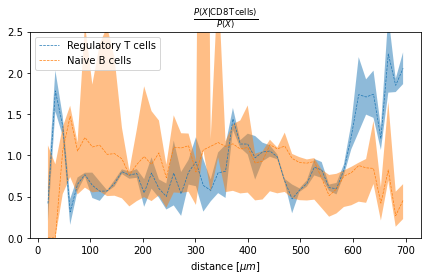

In [172]:
plt.plot(x,np.median(dic[key1],axis = 0),label = key1,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key1], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)

plt.plot(x,np.median(dic[key2],axis = 0),label = key2,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key2], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)
plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CD8 \,T cells})}{P(X)}$')
plt.legend()
plt.tight_layout()
plt.ylim(0,2.5)
#plt.savefig(output_fig+'/co_occurrence_B_Tcells_before.png')

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


<ipython-input-124-452c79bfe22b>:7: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


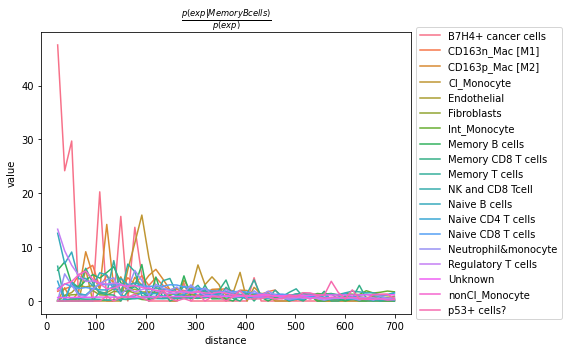

In [124]:
sq.pl.co_occurrence(
    sub_adata,
    cluster_key="AnnoSpat",
    clusters=['Memory B cells'],
    figsize=(8, 5),
)
plt.tight_layout()
#plt.savefig(output_fig+'/co_occurrence_all.png')

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


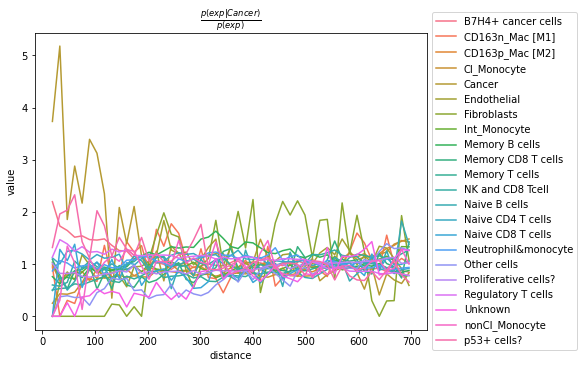

In [185]:
sq.pl.co_occurrence(
    ROI_1,
    cluster_key="AnnoSpat",
    clusters=['Cancer'],
    figsize=(8, 5),
)

In [21]:
cell_type_totals = pd.read_csv('../IMC_SegmentationResults/IMCCelltypeResults/CellTypeTotals.csv')
cell_type_totals.head()

,Image,CellType,Total,Density,Total_highProb,Density_highProb,Area_highProb,Max_probability_area,Max_probability_area_percentage
0,Leap001_ROI_001,Cancer,140.336744,0.000122,0.000000,0.000000,0.000000,0,0.000000
1,Leap001_ROI_001,CD163p_Mac..M2.,1726.340928,0.001505,31.445619,0.000027,0.000172,37,0.003226
2,Leap001_ROI_001,CD163n_Mac..M1.,6245.313083,0.005446,1.636302,0.000001,0.000013,4,0.000349
3,Leap001_ROI_001,Naive.CD4.T.cells,18.398982,0.000016,3.855173,0.000003,0.000022,7,0.000610
4,Leap001_ROI_001,Memory.T.cells,6.909340,0.000006,1.678131,0.000001,0.000010,2,0.000174


In [204]:
sc.pl.dotplot(adata, var_names = marker_list, groupby = groupby,return_fig=True)

source_file  ROI
Leap001_008  1      11285
Leap002_007  2       8471
Leap002_006  3       7998
Leap002_004  5       7486
Leap002_005  4       7418
Leap002_003  7       6399
Leap001_009  2       4741
Leap001_010  3       4233
dtype: int64

In [81]:
!conda remove pandas

Solving environment: failed

PackagesNotFoundError: The following packages are missing from the target environment:
  - pandas


